In [1]:
# %matplotlib widget
import sys
sys.path.append('..')

import os
import sys
import numpy as np
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
from mpl_toolkits import mplot3d
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
import math
from IPython.display import HTML
from tqdm import tqdm
import random
from numpy.lib import recfunctions as rfn
import multiprocessing

from sklearn.cluster import DBSCAN
from scipy.interpolate import interp1d
from scipy.spatial import KDTree
from scipy.interpolate import interpn
# import cupy as cp
import time
import numba as nb

# 画图部分
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid
from functools import partial
import matplotlib.cm as cm

# ROC曲线部分
from sklearn.metrics import roc_curve, auc
from sklearn import metrics

# 插值
import torch
import torch.cuda as cuda
from scipy.interpolate import griddata

# 系数拟合部分
from scipy.optimize import curve_fit
from sklearn import svm


# 概率比较部分
from scipy.special import gammaln
import torch.distributions as dist

# 位置重建函数
import position_rec as pos

import DE
from DE import DESimulation
import importlib

# from thundersvm import SVC

Trans into torch tensor input


In [2]:
importlib.reload(DE)
importlib.reload(plt)
from DE import DESimulation

In [3]:
def rndm(a, b, g, size=1):
    """Power-law gen for pdf(x)\propto x^{g-1} for a<=x<=b"""
    r = np.random.random(size=size)
    ag, bg = a**g, b**g
    return (ag + (bg - ag)*r)**(1./g)

def dense_muon_gen(modified_merged_muon_array, interp_num, event_time, dead_time_ratio):
    '''生成dense_muon_points数据, 为保证速度，从muon track的首尾线性插值，并且能量均匀分布'''

    # 定义每个元素的类型
    element_types = [('eventId', '<i4'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'),
                     ('zd', '<f8'), ('muon_time', '<f8'), ('num_e', '<u4'), ('num_e_delayed', '<u4')]
    # 定义muon模拟数量
    muon_sim_num = (modified_merged_muon_array['eventId'][-1] + 1)
    dense_muon_points = np.zeros(
        int(muon_sim_num*interp_num), dtype=element_types)
    # 获取modified_merged_muon_array中每个eventId刷新坐标
    unique_elements, start_indices = np.unique(
        modified_merged_muon_array['eventId'], return_index=True)
    end_indices = np.concatenate(
        [start_indices[1:] - 1, np.array([len(modified_merged_muon_array)-1,])])

    start_point, end_point = modified_merged_muon_array[
        start_indices], modified_merged_muon_array[end_indices]
    gap_x = - start_point['xd'] + end_point['xd']
    gap_y = - start_point['yd'] + end_point['yd']
    gap_z = - start_point['zd'] + end_point['zd']

    # 创建长度为100的0-1之间差值数组
    arr = np.tile(np.arange(0, 100/99, 1/99), (muon_sim_num, 1))
    x_dense, y_dense, z_dense = arr * \
        gap_x[:, np.newaxis], arr * \
        gap_y[:, np.newaxis], arr * gap_z[:, np.newaxis]
    x_dense, y_dense, z_dense = x_dense + start_point['xd'][:, np.newaxis], y_dense + \
        start_point['yd'][:, np.newaxis], z_dense + \
        start_point['zd'][:, np.newaxis]

    dense_muon_points['xd'], dense_muon_points['yd'], dense_muon_points['zd'] = x_dense.flatten(
    ), y_dense.flatten(), z_dense.flatten()
    dense_muon_points['eventId'] = (
        np.arange(muon_sim_num*interp_num)/100).astype('uint32')

    # 计算每个muon沉积能量总和及电子总和

    # 提取 eventId 和 electron_num 列
    event_ids = modified_merged_muon_array['eventId']
    electron_nums = modified_merged_muon_array['electronNum']
    muon_step_energy = modified_merged_muon_array['energy']

    # 使用 numpy.unique 获取唯一 eventId 和对应的索引
    unique_event_ids, event_id_indices = np.unique(
        event_ids, return_inverse=True)

    # 使用 numpy.bincount 计算每个相同 eventId 的 electron_num 总和
    muon_electron_sum = np.bincount(event_id_indices, weights=electron_nums)
    muon_electron_energy = np.bincount(
        event_id_indices, weights=muon_step_energy)
    muon_electron_sum.astype('uint32')

    # 补全dense_muon_points中的energy，num_e以及num_e_delayed
    average_electron = (muon_electron_sum/100).astype('uint32')
    average_energy = (muon_electron_energy/100).astype('uint32')

    dense_muon_points['energy'] = average_energy[dense_muon_points['eventId']]
    dense_muon_points['num_e'] = average_electron[dense_muon_points['eventId']]
    dense_muon_points['muon_time'] = event_time[dense_muon_points['eventId']]

    # 定义残留比例
    delay_ratio = ((dense_muon_points['zd']-100) / (-1.7) / 1000 + 0.02) / 100
    delay_ratio[delay_ratio < 0.001] = 0.001
    dense_muon_points['num_e_delayed'] = dense_muon_points['num_e'] * \
        delay_ratio * dead_time_ratio

    return dense_muon_points

In [4]:
file_load_once = 10
param = 0

cevns_sim = DESimulation('DE_param_30_test.yaml')

# test_cevns_sim.pe_gain_std = 2.4e6

muon_file_list = []
for i in range(file_load_once):
    # print(i)
    file_index = param * file_load_once + i
    filename = cevns_sim.load_folder_path + \
        "muon_track/muon_track." + str(file_index) + ('.npy')
    # print(filename)
    muon_file_list.append(filename)

载入处理速度文件并分析
====

In [8]:
k_list = np.linspace(0,2,10)
k_list = 10**(k_list)
k_list = k_list.astype('int')

time_linear_list = np.load("time_linear_list.npy")
time_pool_10_noreturn_list = np.load("time_pool_10_noreturn_list.npy")
time_pool_10_noreturn_copy_list = np.load("time_pool_10_noreturn_copy_list.npy")
time_pool_8_8ch_list = np.load("time_pool_8_8ch_list.npy")

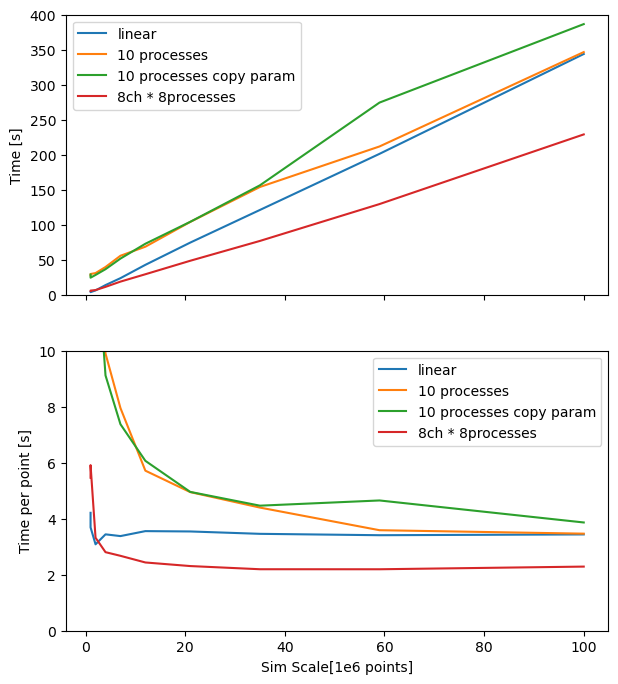

In [15]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(7 ,8))

#画第一个子图
axs[0].plot(k_list, time_linear_list, label = 'linear')
axs[0].plot(k_list, time_pool_10_noreturn_list, label = '10 processes')
axs[0].plot(k_list, time_pool_10_noreturn_copy_list, label = '10 processes copy param')
axs[0].plot(k_list, time_pool_8_8ch_list, label = '8ch * 8processes')
axs[0].legend()
axs[0].set_ylim(0, 400)
axs[0].set_ylabel("Time [s]") 

#画第二个子图
axs[1].plot(k_list, np.array(time_linear_list) / k_list, label = 'linear')
axs[1].plot(k_list, np.array(time_pool_10_noreturn_list) / k_list , label = '10 processes')
axs[1].plot(k_list, np.array(time_pool_10_noreturn_copy_list) / k_list , label = '10 processes copy param')
axs[1].plot(k_list, np.array(time_pool_8_8ch_list) / k_list , label = '8ch * 8processes')
axs[1].legend()
axs[1].set_ylim(0, 10)
axs[1].set_xlabel("Sim Scale[1e6 points]") 
axs[1].set_ylabel("Time per point [s]")

plt.show()

In [19]:
rate = 3e5
rate * (1.5/1e6)**1 * rate * 3600 * 24 * 365

4257360000000.0

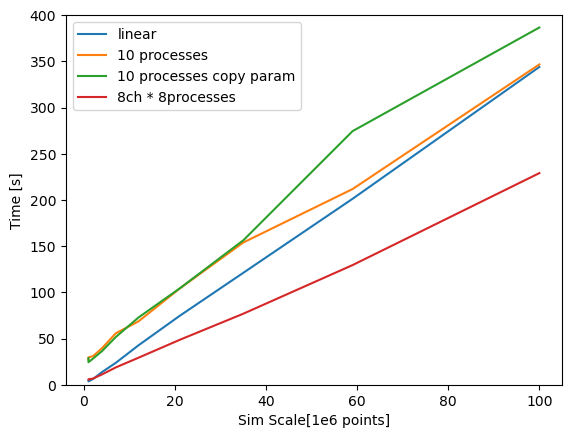

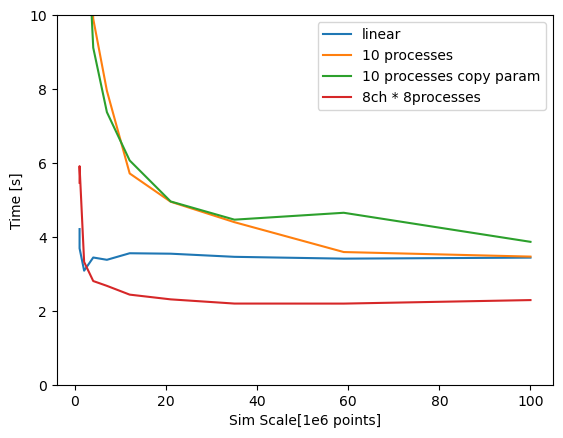

In [9]:
plt.figure()
plt.plot(k_list,time_linear_list,label = 'linear')
plt.plot(k_list,time_pool_10_noreturn_list,label = '10 processes')
plt.plot(k_list,time_pool_10_noreturn_copy_list,label = '10 processes copy param')
plt.plot(k_list,time_pool_8_8ch_list,label = '8ch * 8processes')
plt.legend()
plt.ylim(0,400)
plt.xlabel("Sim Scale[1e6 points]")
plt.ylabel("Time [s]")
# plt.savefig("Speed.pdf",dpi = 200)
plt.show()

plt.figure()
plt.plot(k_list,np.array(time_linear_list) / k_list,label = 'linear')
plt.plot(k_list,np.array(time_pool_10_noreturn_list) / k_list ,label = '10 processes')
plt.plot(k_list,np.array(time_pool_10_noreturn_copy_list) / k_list ,label = '10 processes copy param')
plt.plot(k_list,np.array(time_pool_8_8ch_list) / k_list ,label = '8ch * 8processes')
plt.legend()
plt.ylim(0,10)
plt.xlabel("Sim Scale[1e6 points]")
plt.ylabel("Time [s]")
# plt.savefig("Speed_per_file.pdf",dpi = 200)
plt.show()

In [ ]:
cevns_sim.generate_muon_points(muon_file_list)
cevns_sim.generate_CEVNS_points()

 30%|███████████████████████████████████████                                                                                           | 3/10 [00:00<00:00, 19.71it/s]

/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.0.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.1.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.2.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.3.npy


 70%|███████████████████████████████████████████████████████████████████████████████████████████                                       | 7/10 [00:00<00:00, 17.86it/s]

/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.4.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.5.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.6.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.7.npy


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 19.12it/s]


/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.8.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.9.npy
Number of muon events: 31255
merged_muon_array data type: [('eventId', '<i4'), ('type', 'i1'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('td', '<f8')]
dense_muon_points data type:  [('eventId', '<i4'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('muon_time', '<f8'), ('num_e', '<u4'), ('num_e_delayed', '<u4')]


In [6]:
cevns_sim.cevns_e_spectrum,cevns_sim.cevns_e_num

(array([71166, 30694, 13920,  6369,  2882,  1276,   549]),
 array([3, 4, 5, 6, 7, 8, 9]))

In [7]:
cevns_sim.cevns_points[0].shape,cevns_sim.cevns_points[0].dtype

((71166,),
 dtype([('cevnsID', '<i4'), ('pos_original', [('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8')]), ('t', '<f8'), ('num_e', '<f8'), ('light_pattern', '<f8', (128,)), ('pe_pattern', '<u2', (128,)), ('area_pattern', '<f8', (128,)), ('pe_by_area', '<f8', (128,)), ('pos_recon', [('xd', '<f8'), ('yd', '<f8')]), ('recons_light_pattern', '<f8', (128,)), ('st_cor', '<f8'), ('st_cor_new', '<f8')]))

In [8]:
def timer_decorator(func):
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        print(f"{func.__name__} 运行时间: {end_time - start_time}秒")
        return result
    return wrapper

In [42]:
# @timer_decorator
def calculate_pattern(pmt_id, LCE_xs, LCE_ys, LCE_value, xi):
    # print("Interpn for channel: ", pmt_id)
    if len(pmt_id) > 1:
        result = []
        for pmt in pmt_id:
            result.append(interpn((LCE_xs, LCE_ys), LCE_value[pmt], xi, bounds_error=False, fill_value=np.nan))
    else:
        result = interpn((LCE_xs, LCE_ys), LCE_value[pmt_id], xi, bounds_error=False, fill_value=np.nan)
    # print(f"通道:{pmt_id}  开始时间:{start_time}")
    # print(f"通道:{pmt_id}  结束时间:{end_time}")
    # print(f"通道:{pmt_id}  运行时间: {end_time - start_time}秒")
    return result

def calculate_pattern_simple(pmt_id, LCE_xs, LCE_ys, LCE_value):
    print("Interpn for channel: ", pmt_id)
    start_time = time.time()
    xd = np.linspace(0,1,25371200)
    yd = np.linspace(0,1,25371200)
    xi = np.stack((xd, yd), axis=1)
    result = interpn((LCE_xs, LCE_ys), LCE_value[pmt_id], xi, bounds_error=False, fill_value=np.nan)
    end_time = time.time()
    # print(f"通道:{pmt_id}  开始时间:{start_time}")
    # print(f"通道:{pmt_id}  结束时间:{end_time}")
    # print(f"通道:{pmt_id}  运行时间: {end_time - start_time}秒")
    return result
    
def calculate_pattern_gpu(pmt_id, LCE_xs, LCE_ys, LCE_value, xi):
    print("Interpn for channel: ", pmt_id)
    return interpn((LCE_xs, LCE_ys), LCE_value[pmt_id], xi, bounds_error=False, fill_value=np.nan)

In [10]:
len(cevns_sim.cevns_e_num)

7

In [19]:
xi.shape,xi_.shape

((126856, 2), (253712,))

In [35]:
xd_list = []
yd_list = []
for i in range(len(cevns_sim.cevns_e_num)):
    fake_pos = cevns_sim.cevns_points[i]['pos_original']
    xd = fake_pos['xd'].reshape(-1)
    yd = fake_pos['yd'].reshape(-1)
    xd_list.append(xd)
    yd_list.append(yd)
xd = np.concatenate(xd_list)
yd = np.concatenate(yd_list)
xi = np.stack((xd, yd), axis=1)[:100000]
print(len(xi))
xi = np.repeat(xi,10,axis = 0)
print(len(xi))
k_list = np.linspace(0,2,10)
k_list = 10**(k_list)
k_list = k_list.astype('int')
xi_list = []
for k in k_list:
    xi_list.append(np.repeat(xi,k,axis = 0))

100000
1000000


In [36]:
k_list

array([  1,   1,   2,   4,   7,  12,  21,  35,  59, 100])

线性执行
=====

In [39]:
time_linear_list = []
for i in tqdm(range(len(xi_list))):
    xi = xi_list[i]
    start_time = time.time()
    for pmt_id in range(64):
        # calculate_pattern(pmt_id, cevns_sim.LCE_xs, cevns_sim.LCE_ys, cevns_sim.LCE_value_true,xi)
        interpn((cevns_sim.LCE_xs, cevns_sim.LCE_ys), cevns_sim.LCE_value[pmt_id], xi, bounds_error=False, fill_value=np.nan)
    end_time = time.time()
    time_linear = end_time - start_time
    time_linear_list.append(time_linear)
    print(f"运行时间: {end_time - start_time}秒")

 10%|█████████████                                                                                                                     | 1/10 [00:04<00:37,  4.21s/it]

运行时间: 4.2111523151397705秒


 20%|██████████████████████████                                                                                                        | 2/10 [00:07<00:31,  3.91s/it]

运行时间: 3.6908504962921143秒


 30%|███████████████████████████████████████                                                                                           | 3/10 [00:14<00:34,  4.94s/it]

...

运行时间: 121.11185073852539秒


 90%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████             | 9/10 [08:11<01:48, 108.30s/it]

运行时间: 201.25321650505066秒


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [13:54<00:00, 83.49s/it]

运行时间: 343.90472626686096秒


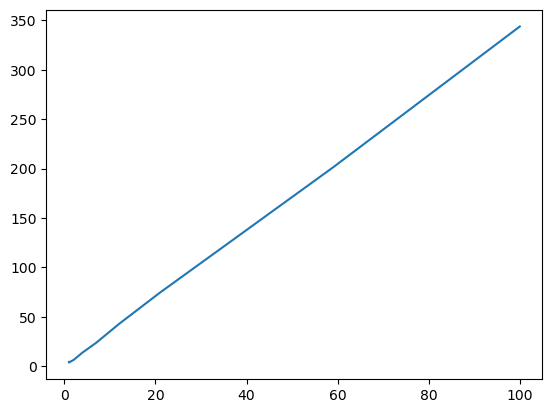

In [40]:
plt.figure()
plt.plot(k_list,time_linear_list)
plt.show()

进程池,10进程,单次运算一个通道，不copy
======

In [41]:
time_pool_10_noreturn_list = []
for i in tqdm(range(len(xi_list))):
    xi = xi_list[i]
    start_time = time.time()
    pool = multiprocessing.Pool(10) #创建一个5个进程的进程池
    for pmt_id in range(64):
        pool.apply_async(func = calculate_pattern, args=(
                pmt_id, cevns_sim.LCE_xs, cevns_sim.LCE_ys, cevns_sim.LCE_value_true, xi,))
    pool.close()
    pool.join()
    end_time = time.time()
    time_pool_10_noreturn_list.append(end_time - start_time)
    print(f"运行时间: {end_time - start_time}秒")

 10%|█████████████                                                                                                                     | 1/10 [00:27<04:08, 27.65s/it]

运行时间: 27.651293754577637秒


 20%|██████████████████████████                                                                                                        | 2/10 [00:57<03:50, 28.80s/it]

运行时间: 29.593666315078735秒


 30%|███████████████████████████████████████                                                                                           | 3/10 [01:28<03:28, 29.76s/it]

...

运行时间: 153.92434191703796秒


 90%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████             | 9/10 [12:01<02:11, 131.83s/it]

运行时间: 211.79540848731995秒


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [17:48<00:00, 106.84s/it]

运行时间: 346.6439468860626秒


In [43]:
# time_pool_10_return_list = []
# for i in tqdm(range(len(xi_list))):
#     xi = xi_list[i]
#     start_time = time.time()
#     pool = multiprocessing.Pool(10) #创建一个5个进程的进程池
#     for pmt_id in range(128):
#         result = pool.apply_async(calculate_pattern, args=(
#             pmt_id, self.LCE_xs, self.LCE_ys, self.LCE_value_true, xi,))
#         results.append(result)
#     # 等待所有任务完成并获取结果
#     results = [result.get() for result in results]
#     end_time = time.time()
#     time_pool_10_return_list.append(end_time - start_time)
#     print(f"运行时间: {end_time - start_time}秒")
# 提交任务并获取结果

进程池,10进程,单次运算一个通道，copy参数（避免访问冲突？）
======

In [44]:
time_pool_10_noreturn_copy_list = []
for i in tqdm(range(len(xi_list))):
    xi = xi_list[i]
    start_time = time.time()
    pool = multiprocessing.Pool(10) #创建一个10个进程的进程池
    for pmt_id in range(64):
        xi_pmt = np.copy(xi)
        pool.apply_async(func = calculate_pattern, args=(
                pmt_id, cevns_sim.LCE_xs, cevns_sim.LCE_ys, cevns_sim.LCE_value_true, xi_pmt,))
    pool.close()
    pool.join()
    end_time = time.time()
    time_pool_10_noreturn_copy_list.append(end_time - start_time)
    print(f"运行时间: {end_time - start_time}秒")

 10%|█████████████                                                                                                                     | 1/10 [00:28<04:18, 28.71s/it]

运行时间: 28.705530405044556秒


 20%|██████████████████████████                                                                                                        | 2/10 [00:53<03:29, 26.14s/it]

运行时间: 24.344403743743896秒


 30%|███████████████████████████████████████                                                                                           | 3/10 [01:21<03:09, 27.11s/it]

...

运行时间: 156.30784058570862秒


 90%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████             | 9/10 [12:57<02:31, 151.75s/it]

运行时间: 274.482670545578秒


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [19:23<00:00, 116.38s/it]

运行时间: 386.608256816864秒


进程池,8进程,单次运算八个通道
=======

In [45]:
time_pool_8_8ch_list = []
for i in tqdm(range(len(xi_list))):
    xi = xi_list[i]
    start_time = time.time()
    pool = multiprocessing.Pool(8) #创建一个8个进程的进程池
    for i in range(8):
        pmt_id_range = np.arange(0,8) + i * 8
        xi_pmt = np.copy(xi)
        pool.apply_async(func = calculate_pattern, args=(
                pmt_id_range, cevns_sim.LCE_xs, cevns_sim.LCE_ys, cevns_sim.LCE_value_true, xi,))
    pool.close()
    pool.join()
    end_time = time.time()
    time_pool_8_8ch_list.append(end_time - start_time)
    print(f"运行时间: {end_time - start_time}秒")

 10%|█████████████                                                                                                                     | 1/10 [00:05<00:49,  5.47s/it]

运行时间: 5.464961290359497秒


 20%|██████████████████████████                                                                                                        | 2/10 [00:11<00:45,  5.73s/it]

运行时间: 5.914314031600952秒


 30%|███████████████████████████████████████                                                                                           | 3/10 [00:18<00:43,  6.15s/it]

...

运行时间: 76.85585570335388秒


 90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████             | 9/10 [05:32<01:10, 70.36s/it]

运行时间: 129.50060606002808秒


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [09:21<00:00, 56.11s/it]

运行时间: 229.01327562332153秒


In [53]:
k_list,len(xi_list[0])

(array([  1,   1,   2,   4,   7,  12,  21,  35,  59, 100]), 1000000)

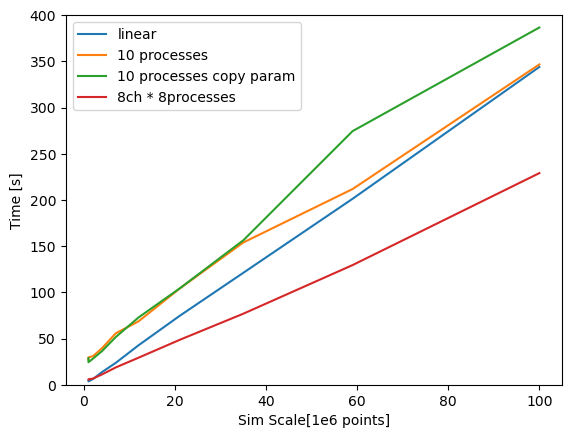

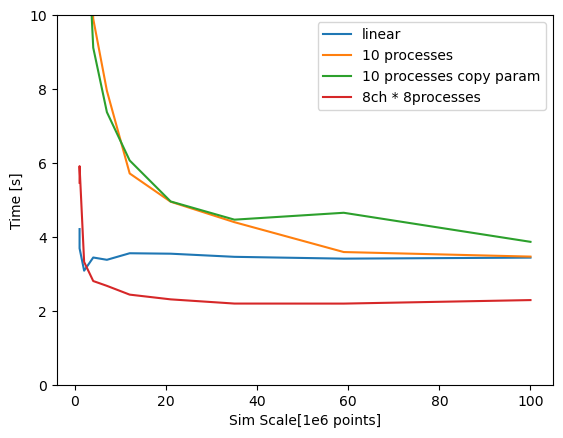

In [61]:
plt.figure()
plt.plot(k_list,time_linear_list,label = 'linear')
plt.plot(k_list,time_pool_10_noreturn_list,label = '10 processes')
plt.plot(k_list,time_pool_10_noreturn_copy_list,label = '10 processes copy param')
plt.plot(k_list,time_pool_8_8ch_list,label = '8ch * 8processes')
plt.legend()
plt.ylim(0,400)
plt.xlabel("Sim Scale[1e6 points]")
plt.ylabel("Time [s]")
plt.savefig("Speed.pdf",dpi = 200)
plt.show()

plt.figure()
plt.plot(k_list,np.array(time_linear_list) / k_list,label = 'linear')
plt.plot(k_list,np.array(time_pool_10_noreturn_list) / k_list ,label = '10 processes')
plt.plot(k_list,np.array(time_pool_10_noreturn_copy_list) / k_list ,label = '10 processes copy param')
plt.plot(k_list,np.array(time_pool_8_8ch_list) / k_list ,label = '8ch * 8processes')
plt.legend()
plt.ylim(0,10)
plt.xlabel("Sim Scale[1e6 points]")
plt.ylabel("Time [s]")
plt.savefig("Speed_per_file.pdf",dpi = 200)
plt.show()

In [55]:
np.save("time_linear_list", time_linear_list)
np.save("time_pool_10_noreturn_list", time_pool_10_noreturn_list)
np.save("time_pool_10_noreturn_copy_list", time_pool_10_noreturn_copy_list)
np.save("time_pool_8_8ch_list", time_pool_8_8ch_list)

In [56]:
x = np.load("time_linear_list.npy")

In [74]:
xi.shape,sys.getsizeof(xi) / (1024**2)

((25371200,), 193.56700134277344)

In [67]:
pool = multiprocessing.Pool(10) #创建一个5个进程的进程池


for pmt_id in range(128):
    pool.apply_async(func = calculate_pattern, args=(
            pmt_id, cevns_sim.LCE_xs, cevns_sim.LCE_ys, cevns_sim.LCE_value_true, xi,))

pool.close()
pool.join()
print('结束测试')

Interpn for channel:  0
通道:0  开始时间:1715593391.4267635
通道:0  结束时间:1715593392.4839363
通道:0  运行时间: 1.0571727752685547秒
Interpn for channel:  1
通道:1  开始时间:1715593392.5627003
通道:1  结束时间:1715593393.4183283
通道:1  运行时间: 0.8556280136108398秒
Interpn for channel:  2
通道:2  开始时间:1715593393.6362996
通道:2  结束时间:1715593394.6003964
通道:2  运行时间: 0.9640967845916748秒
Interpn for channel:  3
Interpn for channel:  4
通道:3  开始时间:1715593394.9087095
通道:3  结束时间:1715593395.7720942
通道:3  运行时间: 0.8633847236633301秒
通道:4  开始时间:1715593395.6834009
通道:4  结束时间:1715593396.3384123
通道:4  运行时间: 0.6550114154815674秒
Interpn for channel:  5
通道:5  开始时间:1715593396.468065
通道:5  结束时间:1715593397.1113036
通道:5  运行时间: 0.6432385444641113秒
Interpn for channel:  6
Interpn for channel:  7
通道:6  开始时间:1715593397.3632429
通道:6  结束时间:1715593398.2229185
通道:6  运行时间: 0.8596756458282471秒
通道:7  开始时间:1715593398.112168
通道:7  结束时间:1715593398.758485
通道:7  运行时间: 0.6463170051574707秒
Interpn for channel:  8
Interpn for channel:  9
通道:8  开始时间:1715593399.02399

In [38]:
results = []
# 创建进程池
with multiprocessing.Pool(processes=10) as pool:
    # 提交任务并获取结果
    for pmt_id in range(20):
        result = pool.apply_async(calculate_pattern, args=(
            pmt_id, cevns_sim.LCE_xs, cevns_sim.LCE_ys, cevns_sim.LCE_value_true, xi,))
        results.append(result)
    pool.close()
    pool.join()
    # result_list = []
    # for res in results:
    #     result_list.append(res.get())

In [26]:
@timer_decorator
def generate_CEVNS_pattern(cevns_sim):
    '''模拟事件根据光模拟结果在顶部的预期通道响应,针对CEVNS事件'''
    xd_list = []
    yd_list = []
    for i in range(len(cevns_sim.cevns_e_num)):
        fake_pos = cevns_sim.cevns_points[i]['pos_original']
        xd = fake_pos['xd'].reshape(-1)
        yd = fake_pos['yd'].reshape(-1)
        xd_list.append(xd)
        yd_list.append(yd)
    xd = np.concatenate(xd_list)
    yd = np.concatenate(yd_list)
    xi = np.stack((xd, yd), axis=1)

    # 定义长度与xi相同的数组数据类型，用于存储一个通道所有事件的响应
    array_dtype = np.dtype((np.float64, (len(xi),)))

    results = []
    # 创建进程池
    with multiprocessing.Pool(processes=10) as pool:
        # 提交任务并获取结果
        for pmt_id in range(128):
            result = pool.apply_async(calculate_pattern, args=(
                pmt_id, cevns_sim.LCE_xs, cevns_sim.LCE_ys, cevns_sim.LCE_value_true, xi,))
            results.append(result)
        # 等待所有任务完成并获取结果
        results = [result.get() for result in results]
    results = np.array(results)
    results = results.T

    # 将所有结果按照事件大小进行切割
    event_num = np.array([len(i) for i in cevns_sim.cevns_points])
    indices = np.cumsum(event_num)
    indices = np.insert(indices, 0, 0)

    cevns_sim.CEVNS_pattern = [
        results[indices[i]:indices[i+1]] for i in range(len(indices)-1)]

    # cevns_sim.CEVNS_light_pattern = []
    # cevns_sim.CEVNS_pe_pattern = []
    # cevns_sim.CEVNS_area_pattern = []
    # cevns_sim.CEVNS_pe_by_area = []

    cevns_sim.cevns_pe_info = []

    for i in range(len(cevns_sim.cevns_e_num)):
        # pattern = cevns_sim.CEVNS_pattern[i]
        # 将pattern分为不同的电子进行处理
        pattern = np.repeat(
            cevns_sim.CEVNS_pattern[i], cevns_sim.cevns_e_num[i], axis=0)
        # 人工增加pe分布系数范围
        gamma = np.random.normal(
            1, 0.265, len(pattern))
        CEVNS_light_pattern = pattern * \
            cevns_sim.single_electron_gain * gamma[:, np.newaxis]

        CEVNS_light_pattern[CEVNS_light_pattern < 0] = 0

        CEVNS_pe_pattern = np.random.poisson(
            CEVNS_light_pattern)

        CEVNS_light_pattern_reshaped = CEVNS_light_pattern.reshape(
            -1, cevns_sim.cevns_e_num[i], CEVNS_light_pattern.shape[1])
        CEVNS_pe_pattern_reshaped = CEVNS_pe_pattern.reshape(
            -1, cevns_sim.cevns_e_num[i], CEVNS_pe_pattern.shape[1])
        CEVNS_light_pattern_sum = np.sum(
            CEVNS_light_pattern_reshaped, axis=1)
        CEVNS_pe_pattern_sum = np.sum(
            CEVNS_pe_pattern_reshaped, axis=1)

        channel_indices_list = []
        event_id_list = []
        pe_area_list = []
        CEVNS_area_pattern_list = []
        pe_e_id = []

        for j in tqdm(range(len(CEVNS_pe_pattern_sum))):
            # 针对每个事件，输pe的event_id,area,channel信息,输出pe响应随机后的patttern
            channel_indices = np.repeat(
                np.arange(128), CEVNS_pe_pattern_sum[j])  # 每个pe对应的channel序号
            # 每个pe对应的pattern序号
            event_id_list.append(np.ones(len(channel_indices))*j)
            pe_area = np.random.normal(
                cevns_sim.pe_gain, cevns_sim.pe_gain_std, size=len(channel_indices))
            pe_area_list.append(pe_area)
            area_pattern = np.bincount(
                channel_indices, weights=pe_area, minlength=128)  # 计算出128个通道每个通道实际响应面积
            area_pattern[area_pattern < 0] = 0
            CEVNS_area_pattern_list.append(area_pattern)
            channel_indices_list.append(channel_indices)

            # 针对每个电子，输出pe的对应电子序号
        for electron_id in tqdm(range(len(CEVNS_pe_pattern))):
            channel_indices = np.repeat(
                np.arange(128), CEVNS_pe_pattern[electron_id])
            pe_e_id.append(
                np.ones(len(channel_indices))*electron_id)

        # 所有pe的对应通道
        channel_indices_array = np.concatenate(channel_indices_list)
        # 所有pe的对应event_id（只针对当前电子数事件）
        event_id_array = np.concatenate(event_id_list)
        # 所有pe的实际面积
        pe_area_array = np.concatenate(pe_area_list)
        # 所有pe的电子id
        pe_e_id = np.concatenate(pe_e_id)
        # 所有事件的各通道面积分布
        CEVNS_area_pattern = np.array(CEVNS_area_pattern_list)

        pe_data = np.zeros(len(channel_indices_array), dtype=cevns_sim.pe_dtype)
        pe_data['event_id'] = event_id_array
        pe_data['area'] = pe_area_array
        pe_data['channel'] = channel_indices_array
        pe_data['e_id'] = pe_e_id
        cevns_sim.cevns_points[i]['light_pattern'] = CEVNS_light_pattern_sum
        cevns_sim.cevns_points[i]['pe_pattern'] = CEVNS_pe_pattern_sum
        cevns_sim.cevns_points[i]['area_pattern'] = CEVNS_area_pattern
        cevns_sim.cevns_points[i]['pe_by_area'] = CEVNS_area_pattern / cevns_sim.pe_gain

        cevns_sim.cevns_pe_info.append(pe_data)

In [27]:
generate_CEVNS_pattern(cevns_sim)

Interpn for channel:  0
Interpn for channel:  1
Interpn for channel:  2
Interpn for channel:  3
Interpn for channel:  4
Interpn for channel:  5
Interpn for channel:  6
Interpn for channel:  7
Interpn for channel:  8
Interpn for channel:  9
Interpn for channel:  10
Interpn for channel:  11
Interpn for channel:  12
Interpn for channel:  13
Interpn for channel:  14
Interpn for channel:  15
Interpn for channel:  16
Interpn for channel:  17
Interpn for channel:  18
Interpn for channel:  19
Interpn for channel:  20
Interpn for channel:  21
Interpn for channel:  22
Interpn for channel:  23
Interpn for channel:  24
Interpn for channel:  25
Interpn for channel:  26
Interpn for channel:  27
Interpn for channel:  28
Interpn for channel:  29
Interpn for channel:  30
Interpn for channel:  31
Interpn for channel:  32
Interpn for channel:  33
Interpn for channel:  34
Interpn for channel:  35
Interpn for channel:  36
Interpn for channel:  37
Interpn for channel:  38
Interpn for channel:  39
Interpn fo

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4941/4941 [00:00<00:00, 160405.39it/s]

generate_CEVNS_pattern 运行时间: 61.46242833137512秒
